# ASP25 (chain A) Environment iGraph Network Plot

**What this notebook does:**
- Reads pre-computed frequency tables describing how often each atom within 5 Å of
  **ASP25 Cα** (chain B) appears across MD simulation frames (one CSV per simulation)
- Filters the data to keep only **Cα atoms** of neighbouring residues
- For each simulation, builds an **iGraph** network:
  - Central node: ASP25 Cα (red)
  - Peripheral nodes: Cα atoms of neighbouring residues, coloured by residue identity
  - Edge width proportional to interaction frequency
  - Chain A residues placed on the left; chain B residues on the right
- Draws all simulation graphs in a multi-panel figure with a shared legend

**Prerequisites:**
Run `02_analysis_env25.ipynb` (or equivalent) first to generate the frequency CSVs.

**Sections:**
1. Install & import libraries
2. Configuration (paths, residue label, chain boundary)
3. Load and parse frequency tables
4. Plot iGraph networks


In [64]:
# 1. Install required libraries
!pip install igraph
!pip install pycairo

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [65]:
# 2. Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import igraph as ig

In [66]:
# 3. Configuration
ROOTDIR    = '/content/drive/MyDrive/M1_STAGE/Manips/Tables/'
OUTPUT_FIG = '/content/drive/MyDrive/M1_STAGE/Manips/Figures/Env25_graph.png'

# Target residue displayed at the centre of each graph
TARGET_LABEL      = 'ASP_25'
CENTRAL_NODE_NAME = 'CA_Asp25_chB'  # must match the value used when building the CSVs
TARGET_DISPLAY    = 'Asp25 Cα'

# Atom-index threshold: < CHAIN_BOUNDARY → chain A; >= → chain B
CHAIN_BOUNDARY = 1536

# Frequency CSVs (one per simulation)
FREQ_DF_PATHS = [
    'V1_ASP_env_atoms_frequency.csv',
    'V11_ASP_env_atoms_frequency.csv',
    'V12_ASP_env_atoms_frequency.csv',
    'V7_ASP_env_atoms_frequency.csv',
    'V8_ASP_env_atoms_frequency.csv',
    'V21_ASP_env_atoms_frequency.csv',
]

os.chdir(ROOTDIR)

In [67]:
# 4. Load and parse frequency tables
df_list                        = []
residue_identifier_set_all_sims = set()

for sim_path in FREQ_DF_PATHS:
    sim_name   = sim_path.replace('_ASP_env_atoms_frequency.csv', '')
    df_sim     = pd.read_csv(sim_path)

    # Keep Cα atoms of neighbours (exclude target residue itself)
    filtered_CA = df_sim[
        df_sim['Residue'].apply(lambda x: 'CA' in x and TARGET_LABEL not in x)
    ].copy()

    df_new             = pd.DataFrame()
    df_new['Source']   = filtered_CA['Residue']
    df_new['Target']   = CENTRAL_NODE_NAME
    df_new['Weight']   = filtered_CA['Frequency'].apply(int)

    chain_labels, res_ids = [], []
    for ca in filtered_CA['Residue'].values:
        parts    = ca.split('_')
        atom_idx = int(parts[0])
        res_id   = '_'.join(parts[2:])
        chain_labels.append('Chain A' if atom_idx < CHAIN_BOUNDARY else 'Chain B')
        res_ids.append(res_id)
        residue_identifier_set_all_sims.add(res_id)

    df_new['Chain']      = chain_labels
    df_new['Residue_Id'] = res_ids
    df_list.append((sim_name, df_new))

# Assign reproducible colours per residue
residue_id_color_dico = {}
for i, res_id in enumerate(sorted(residue_identifier_set_all_sims)):
    np.random.seed(i)
    residue_id_color_dico[res_id] = tuple(np.random.choice(256, 3) / 255.0)

print(f'Loaded {len(df_list)} simulation(s), '
      f'{len(residue_identifier_set_all_sims)} unique residue identifiers.')

Loaded 6 simulation(s), 19 unique residue identifiers.


/tmp/ipykernel_2171/2889182554.py:81: UserWarning:

Setting the 'color' property will override the edgecolor or facecolor properties.

/tmp/ipykernel_2171/2889182554.py:83: UserWarning:

Setting the 'color' property will override the edgecolor or facecolor properties.



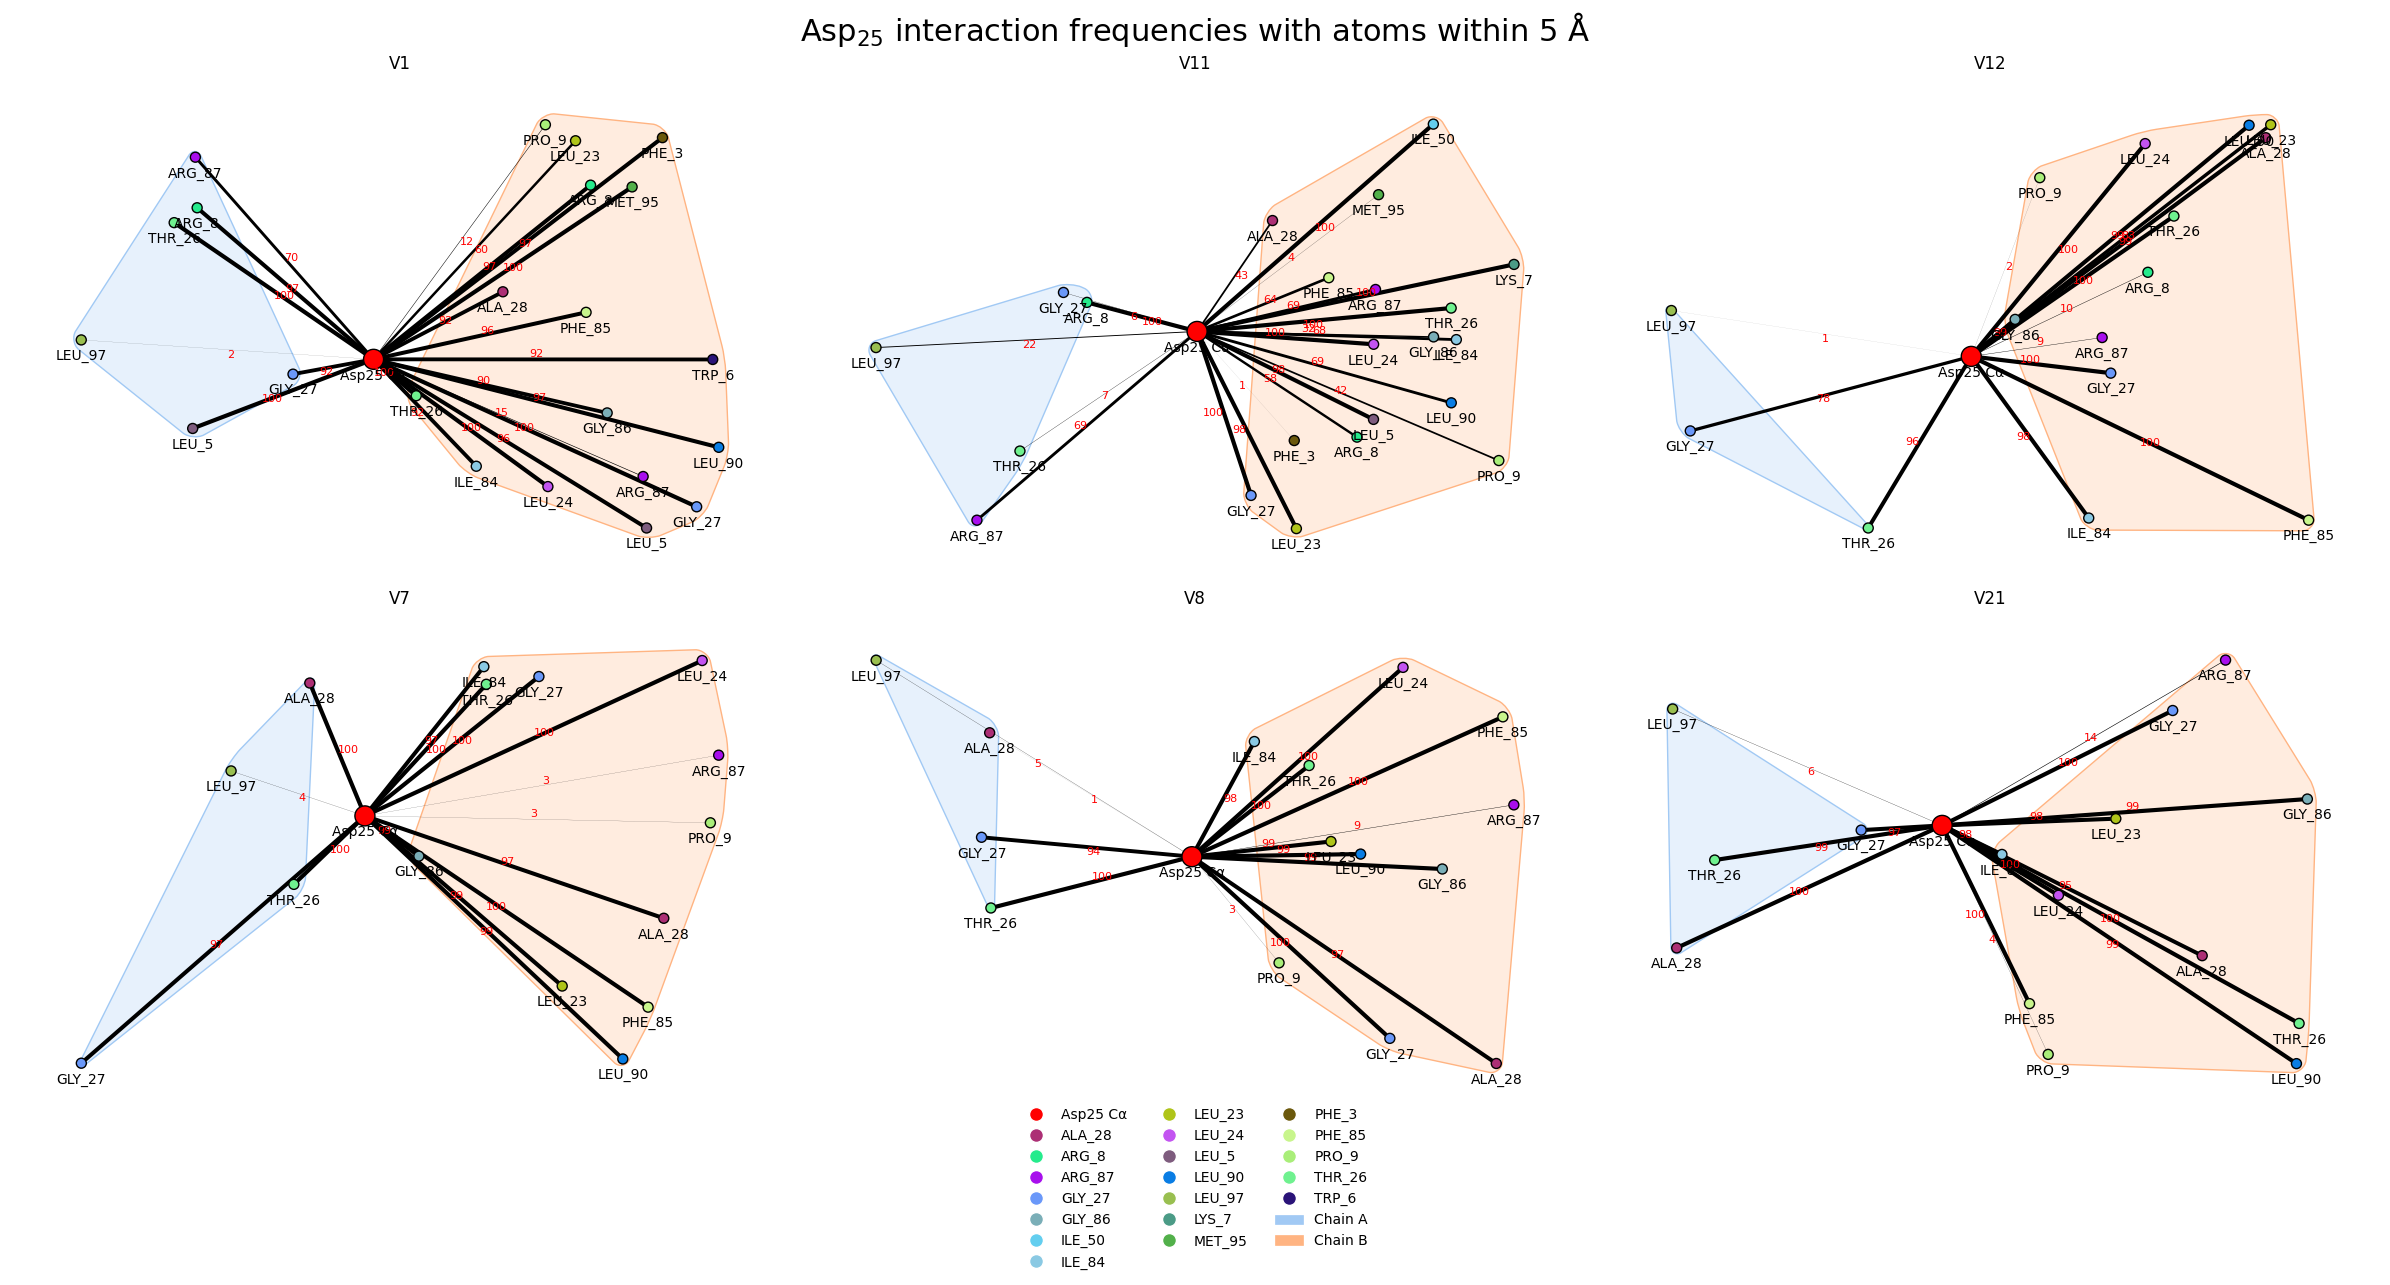

Figure saved to /content/drive/MyDrive/M1_STAGE/Manips/Figures/Env25_graph.png


In [68]:
# 5. Plot iGraph networks — one panel per simulation
chain_colors = {'Chain A': '#a1c9f4', 'Chain B': '#ffb482'}

num_cols = 3
num_rows = (len(df_list) + num_cols - 1) // num_cols
fig, axes = plt.subplots(num_rows, num_cols,
                          figsize=(num_cols * 8, num_rows * 6), squeeze=False)
axes = axes.flatten()
fig.suptitle(f'Asp$_{{25}}$ interaction frequencies with atoms within 5 Å',
             fontsize=22)

for plot_idx, (sim_name, sim_df) in enumerate(df_list):
    ax = axes[plot_idx]
    ax.set_title(sim_name)

    g = ig.Graph.DataFrame(sim_df, directed=False, use_vids=False)

    chain_map  = sim_df.set_index('Source')['Chain'].to_dict()
    res_id_map = sim_df.set_index('Source')['Residue_Id'].to_dict()

    for v in g.vs:
        if v['name'] == CENTRAL_NODE_NAME:
            v['chain']              = 'Chain B'
            v['residue_identifier'] = TARGET_LABEL
        else:
            v['chain']              = chain_map.get(v['name'], 'Unknown')
            v['residue_identifier'] = res_id_map.get(v['name'], 'Unknown')

    colors, labels, sizes = [], [], []
    group_A, group_B, layout = [], [], []

    for i, v in enumerate(g.vs):
        if v['name'] == CENTRAL_NODE_NAME:
            colors.append((1.0, 0.0, 0.0))
            labels.append('\n\n' + TARGET_DISPLAY)
            sizes.append(20)
            layout.append([0.0, 0.0])
        else:
            colors.append(residue_id_color_dico.get(v['residue_identifier'], (0.5, 0.5, 0.5)))
            labels.append('\n\n' + v['residue_identifier'])
            sizes.append(10)
            if v['chain'] == 'Chain A':
                group_A.append(i)
                layout.append([np.random.uniform(-0.9, -0.1), np.random.uniform(-0.7, 0.7)])
            elif v['chain'] == 'Chain B':
                group_B.append(i)
                layout.append([np.random.uniform(0.1, 0.9), np.random.uniform(-0.7, 0.7)])
            else:
                layout.append([np.random.uniform(-0.1, 0.1), np.random.uniform(-0.1, 0.1)])

    weights     = [w for w in g.es['Weight'] if w > 0]
    edge_widths = [(w / 50) * 1.5 for w in weights]

    ig.plot(g, target=ax,
            vertex_size=sizes, vertex_color=colors,
            vertex_label=labels, vertex_label_size=10,
            edge_width=edge_widths, edge_curved=0,
            edge_label=weights, edge_label_size=8,
            edge_color='black', edge_label_color='red',
            layout=layout, bbox=(400, 400),
            mark_groups=[(group_A, chain_colors['Chain A']),
                         (group_B, chain_colors['Chain B'])],
            margin=20)

# Hide unused panels
for j in range(len(df_list), len(axes)):
    fig.delaxes(axes[j])

# Build shared legend
legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=(1.0, 0.0, 0.0), markersize=10,
               label=TARGET_DISPLAY)
]
for res_id, color in sorted(residue_id_color_dico.items()):
    legend_handles.append(
        plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=color, markersize=10, label=res_id)
    )
legend_handles += [
    mpatches.Patch(color=chain_colors['Chain A'], label='Chain A',
                   edgecolor='black', linewidth=0.5),
    mpatches.Patch(color=chain_colors['Chain B'], label='Chain B',
                   edgecolor='black', linewidth=0.5),
]

fig.legend(handles=legend_handles, loc='lower center',
           ncol=3, fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.08))
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()
fig.savefig(OUTPUT_FIG, bbox_inches='tight', dpi=150)
print(f'Figure saved to {OUTPUT_FIG}')